**IBM HR ANALYTICS EMPLOYEE ATTRITION AND PERFORMANCE**

**STEP-1** - Problem Statement

Organizations face significant costs when employees leave their jobs. High employee turnover can result in:
* increased recruitment costs
* loss of experienced talent
* reduced productivity
* disruption in team performance

Therefore, companies do want to understand **why employees QUIT** and identify the factors that contribute to employee attrition.

In this project I performed Exploratory Data Analysis (EDA) on employee data to discover patterns and relationships that may explain employee attrition.

My goal is to identify key factors that influence whether an employee decides to leave the organization.

**Business Problem** - Human Resource (HR) teams want to answer questions like:

* Which employees are more likely to leave?
* Does salary affect attrition?
* Does overtime increase employee turnover?
* Do younger employees leave more frequently?
* Does job satisfaction influence attrition?

Understanding these factors allows organizations to:

* identify employees at risk of leaving
* improve work-life balance policies
* optimize compensation strategies
* reduce recruitment costs
* improve employee satisfaction

**STEP-2** - Loading the Dataset

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import math

In [66]:
pd.set_option('display.max_columns', None)

In [67]:
df = pd.read_csv("Employee-Attrition.csv")

In [68]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [69]:
df.shape

(1470, 35)

In [70]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [71]:
print(df.columns.tolist())

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [72]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


**STEP-4** - Dataset Overview

The dataset contains information about employees working in an organization and their job-related attributes.
* Total Records: 1470 employees
* Total Features: 35 variables
* Target Variable: Attrition

Attrition indicates whether an employee left the company or stayed. (Yes-Employee left the company, No- Employee stayed)

Numerical Columns - 26
* Age -[1,80] - Age of employee
* DailyRate -[102,1499]	- Daily salary rate
* DistanceFromHome -[1,	29] - Distance between home and workplace
* Education -[1,5] - Education level
* EnvironmentSatisfaction -[1,4] - Satisfaction with work environment
* HourlyRate -[30,100] - Hourly salary rate
* JobInvolvement -[1,4] - Level of employee involvement
* JobLevel -[1,	5] - Job hierarchy level
* JobSatisfaction -[1,4] - Employee job satisfaction
* MonthlyIncome -[1009,19999] - Monthly salary
* MonthlyRate -[2094,26999] - Monthly pay rate
* NumCompaniesWorked -[0,9] - Number of companies worked previously
* PercentSalaryHike -[11,25] - Percentage salary increase
* PerformanceRating -[3,4] - Performance rating
* RelationshipSatisfaction -[1,4] - Relationship satisfaction at work
* StockOptionLevel -[0,3] -	Stock option level
* TotalWorkingYears -[0,40] - Total career experience
* TrainingTimesLastYear -[0,6] - Training sessions last year
* WorkLifeBalance -[1,4] - Work-life balance rating
* YearsAtCompany -[0,40] - Years spent at current company
* YearsInCurrentRole -[0,18] - Years in current role
* YearsSinceLastPromotion -[0,15] -	Years since last promotion
* YearsWithCurrManager -[0,17] - Years with current manager

Categorical Columns - 9
* Attrition	Employee - leaving status
* BusinessTravel - Travel frequency
* Department - Department of employee
* EducationField - Field of education
* Gender - Male/Female
* JobRole - Role in company
* MaritalStatus - Married/Single/Divorced
* Over18 - Age eligibility
* OverTime - Whether employee works overtime

**STEP-4** - Data Cleaning

4.1 Missing Values Check

In [73]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

The dataset does not contain any missing values. All 35 columns have complete records for the 1470 employees. Therefore, no missing value imputation is required.

4.2 Duplicate Records

In [74]:
df.duplicated().sum()

0

No duplicate rows were found in the dataset, which implies that each employee record is unique.

4.3 Identify Constant Columns

Some columns might contain only a single value and do not contribute to analysis.

In [75]:
df.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

4.4 Droppong useless Columns 

In [76]:
df.drop(['EmployeeCount','EmployeeNumber','StandardHours','Over18'], axis=1, inplace=True)

In [77]:
df.shape

(1470, 31)

**STEP-5** - Univariate Analysis

In [78]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

Target Variable Analysis

In [79]:
attrition_counts = df['Attrition'].value_counts().reset_index()
attrition_counts.columns = ['Attrition','Count']

In [81]:
fig = px.bar(
    attrition_counts,
    x='Attrition',
    y='Count',
    color='Attrition',
    text='Count', 
    title='Employee Attrition Distribution'
)

fig.update_traces(textposition='outside') 

fig.show()

It shows relatively low attrition rate (~16%), indicating that most employees stay with the company.

And also the dataset is highly imbalanced, where the majority class (No) dominates the dataset.

Numerical Univariate Analysis

In [ ]:
num_cols = [
    "Age", "MonthlyIncome", "DistanceFromHome",
    "TotalWorkingYears", "YearsAtCompany", "YearsInCurrentRole",
    "YearsSinceLastPromotion", "YearsWithCurrManager",
    "NumCompaniesWorked", "PercentSalaryHike"
]

cols_count = 3
rows_count = math.ceil(len(num_cols) / cols_count)

fig = make_subplots(
    rows=rows_count, 
    cols=cols_count, 
    subplot_titles=num_cols,
    vertical_spacing=0.1 
)

for i, col in enumerate(num_cols):
    row = (i // cols_count) + 1
    c = (i % cols_count) + 1
    
    fig.add_trace(
        go.Histogram(x=df[col], name=col, nbinsx=30),
        row=row, col=c
    )

fig.update_layout(
    height=300 * rows_count, 
    width=1000, 
    title_text="<b>Distribution of IBM Employee Numerical Features</b>",
    showlegend=False,
    template="plotly_white"
)

fig.show()

Categorical Univariate Analysis

In [ ]:
cat_cols = [
    "Department", "JobRole", "OverTime", 
    "MaritalStatus", "Gender", "BusinessTravel"
]

cols_count = 2
rows_count = math.ceil(len(cat_cols) / cols_count)

fig = make_subplots(
    rows=rows_count, 
    cols=cols_count, 
    subplot_titles=cat_cols,
    vertical_spacing=0.15
)

for i, col in enumerate(cat_cols):
    row = (i // cols_count) + 1
    c = (i % cols_count) + 1
    
    counts = df[col].value_counts()
    
    fig.add_trace(
        go.Bar(
            x=counts.index, 
            y=counts.values, 
            text=counts.values,
            textposition='auto',
            name=col
        ),
        row=row, col=c
    )

fig.update_layout(
    height=400 * rows_count, 
    width=1000, 
    title_text="<b>Distribution of IBM Employee Categorical Features</b>",
    showlegend=False,
    template="plotly_white"
)

fig.update_xaxes(tickangle=45)

fig.show()

Key Observations with Percentages
* Research & Development has 961 employees, which is 65.4% of the workforce, making it the dominant department.
* Sales Executives (326 employees – 22.2%) and Research Scientists (292 employees – 19.9%) together form a large portion of the company’s workforce.
* Most employees do not work overtime: 1054 employees (71.7%), while only 416 employees (28.3%) work overtime.
* Married employees are the largest group with 673 employees (45.8%), followed by Single (32.0%) and Divorced (22.2%).
* The company is male-dominated, with 882 male employees (60.0%) compared to 588 female employees (40.0%).
* Business travel is relatively limited: Travel_Rarely accounts for 1043 employees (70.9%), compared to Travel_Frequently (18.8%) and Non-Travel (10.2%).

**STEP-6** - Bivariate Analysis

Sttrition vs Work Factors(Overtime, Business Travel, work life balance)

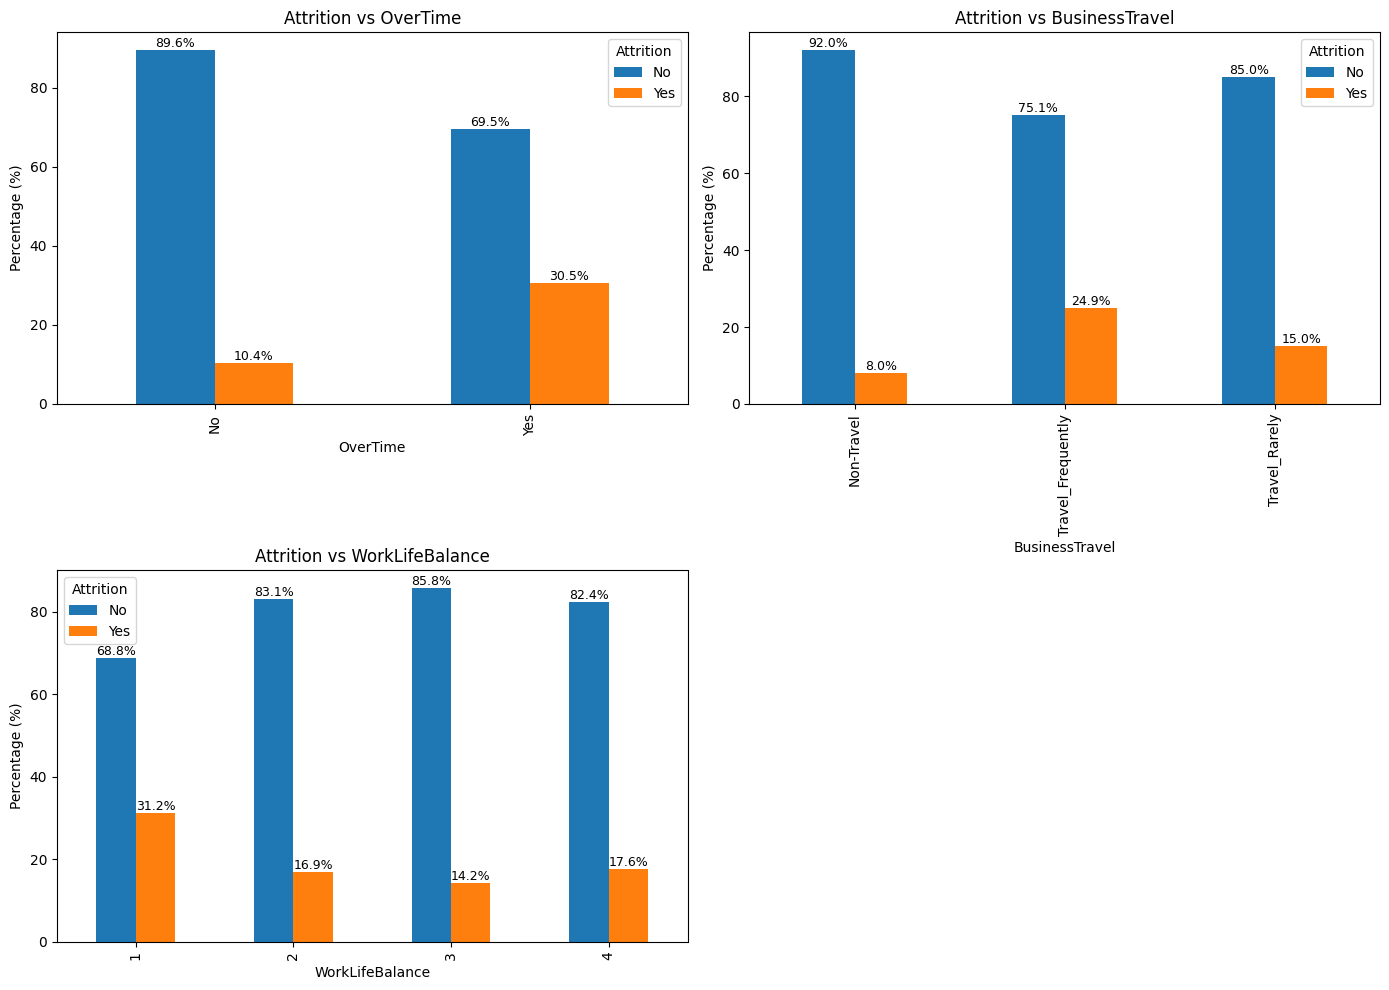

In [48]:
work_factors = ["OverTime", "BusinessTravel", "WorkLifeBalance"]

rows = int(np.ceil(len(work_factors)/2))

fig, axes = plt.subplots(rows, 2, figsize=(14,5*rows))
axes = axes.flatten()

for i, col in enumerate(work_factors):
    
    temp = pd.crosstab(df[col], df["Attrition"], normalize="index")*100
    temp.plot(kind="bar", ax=axes[i])
    
    axes[i].set_title(f"Attrition vs {col}")
    axes[i].set_ylabel("Percentage (%)")
    axes[i].set_xlabel(col)
    axes[i].legend(title="Attrition")
    
    for p in axes[i].patches:
        axes[i].annotate(
            f"{p.get_height():.1f}%",
            (p.get_x()+p.get_width()/2, p.get_height()),
            ha='center',
            va='bottom',
            fontsize=9
        )

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

* Employees who work overtime have almost 3× higher attrition rate compared to employees who do not work overtime. Overtime appears to be a major driver of employee burnout and dissatisfaction, leading to significantly higher employee turnover.
* Attrition increases as travel frequency increases. Employees who travel frequently have the highest attrition rate (~25%), which is 3× higher than employees who do not travel.
* Employees with poor work-life balance (level 1) have the highest attrition rate (~31%), which is more than double compared to employees with better balance. Employees with balanced work-life levels (3–4) show significantly lower attrition.

*Workload-related factors such as overtime, frequent travel, and poor work-life balance show a strong relationship with employee attrition, indicating that job stress and lifestyle imbalance significantly influence employee turnover.*

In [39]:
pd.crosstab(
    df["OverTime"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


Attrition vs Job Factors

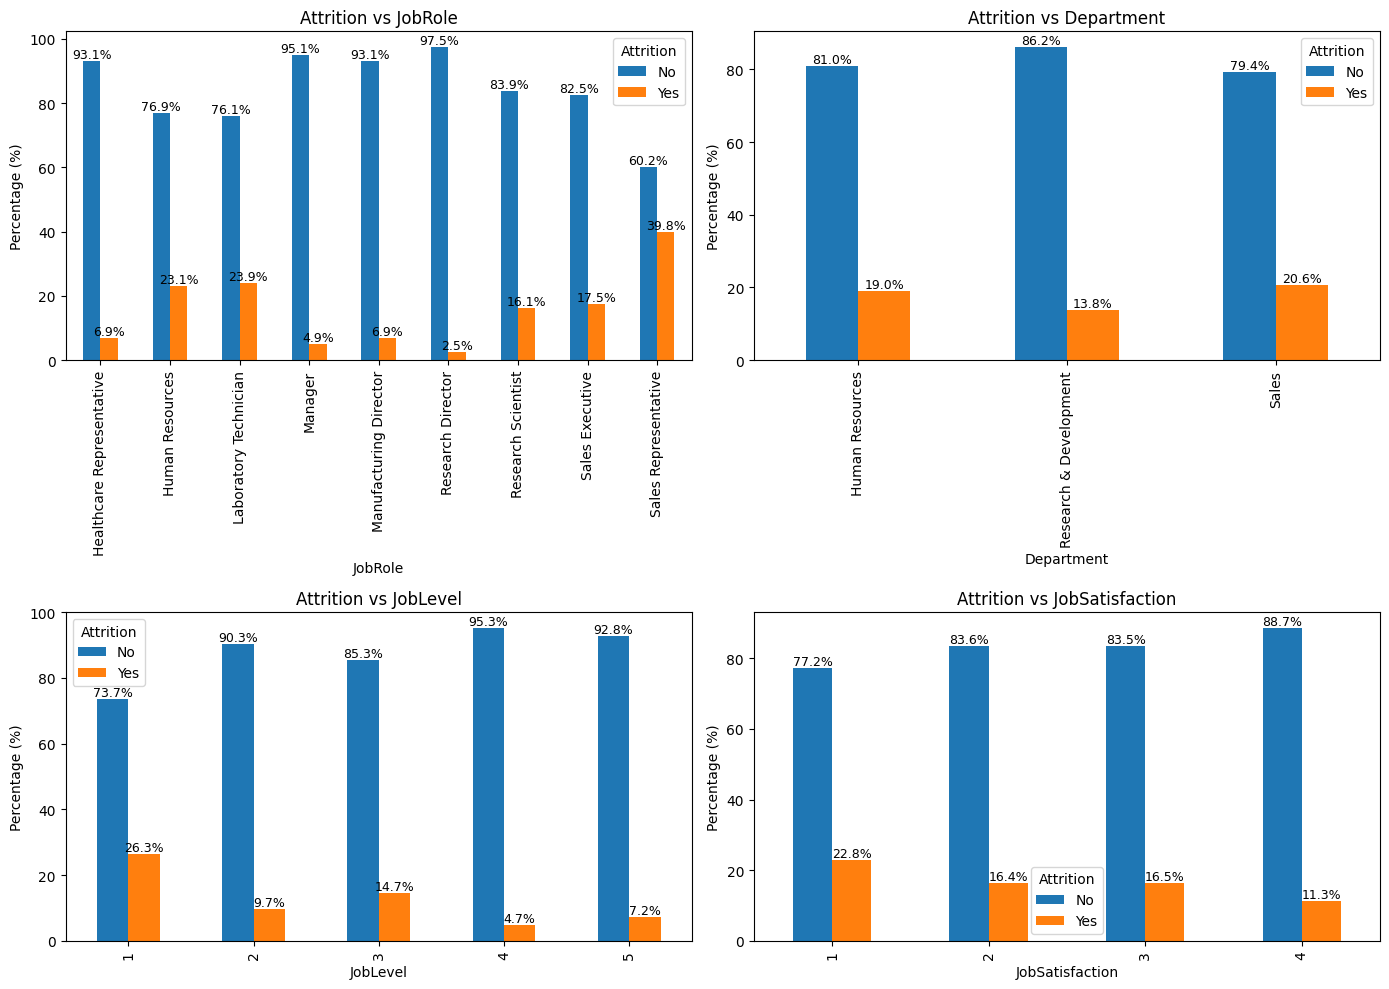

In [49]:
job_factors = ["JobRole", "Department", "JobLevel", "JobSatisfaction"]

rows = int(np.ceil(len(job_factors)/2))

fig, axes = plt.subplots(rows, 2, figsize=(14,5*rows))
axes = axes.flatten()

for i, col in enumerate(job_factors):

    temp = pd.crosstab(df[col], df["Attrition"], normalize="index")*100
    temp.plot(kind="bar", ax=axes[i])

    axes[i].set_title(f"Attrition vs {col}")
    axes[i].set_ylabel("Percentage (%)")
    axes[i].set_xlabel(col)

    for p in axes[i].patches:
        axes[i].annotate(
            f"{p.get_height():.1f}%",
            (p.get_x()+p.get_width()/2, p.get_height()),
            ha='center',
            va='bottom',
            fontsize=9
        )

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

* Sales Representatives have the highest attrition (39.8%), followed by Laboratory Technicians (23.9%) and HR (23.1%). Senior roles like Research Directors (2.5%) and Managers (4.9%) show very low attrition. This indicates entry-level and sales-oriented roles experience higher employee turnover.
* The Sales department has the highest attrition (20.6%), followed by HR (19.0%), while R&D has the lowest attrition (13.8%). Nearly 1 in 5 employees leave the Sales department, indicating higher turnover in revenue-driven roles.
* Attrition is highest at Job Level 1 (26.3%) and drops significantly in higher levels, reaching 4.7% at Level 4 and 7.2% at Level 5. This suggests entry-level employees are more likely to leave compared to senior employees.
* Employees with low satisfaction (Level 1) have 22.8% attrition, while those with high satisfaction (Level 4) have only 11.3% attrition. This shows that higher job satisfaction is associated with lower employee turnover.

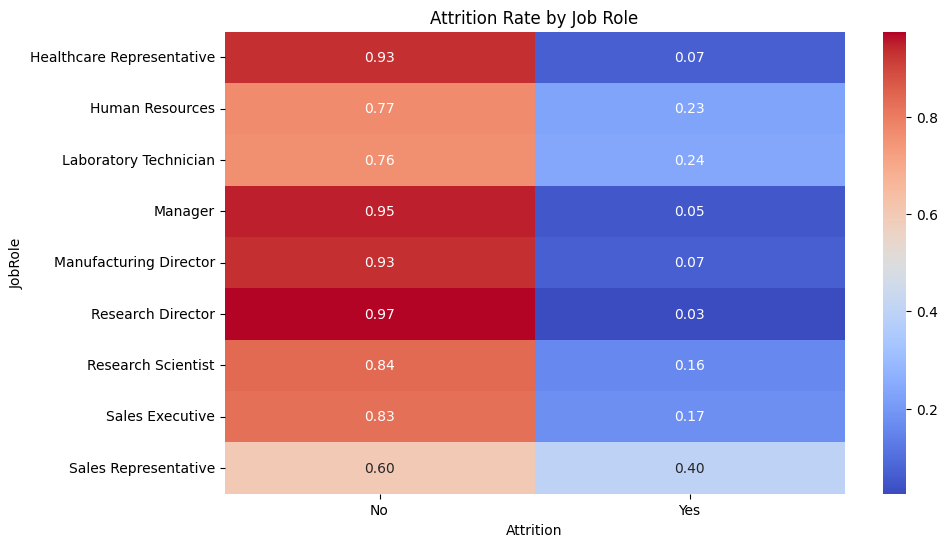

In [ ]:
import seaborn as sns

pivot = pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Attrition Rate by Job Role")
plt.show()

* Sales Representatives have the highest attrition rate at 40%, far exceeding any other role.
* Roles like Research Director (3%), Manager (5%), and Healthcare Representative (7%) show exceptional retention rates.
* Laboratory Technicians (24%) and Human Resources (23%) also represent high-risk groups that require attention.

Attrition vs Experience

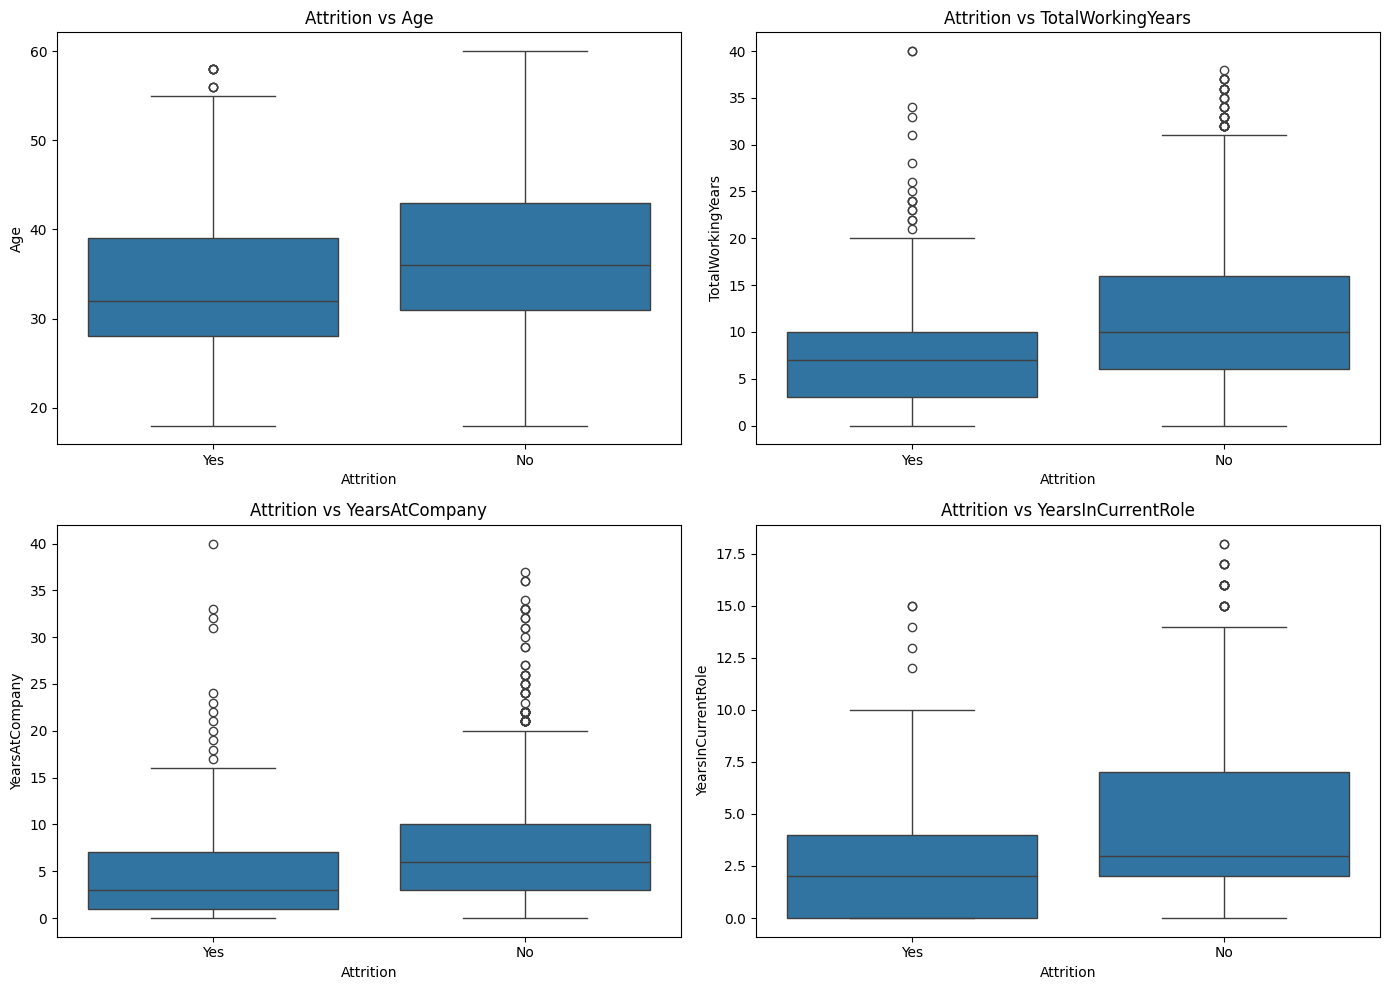

In [50]:
experience_features = [
    "Age",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole"
]

rows = int(np.ceil(len(experience_features)/2))

fig, axes = plt.subplots(rows,2, figsize=(14,5*rows))
axes = axes.flatten()

for i, col in enumerate(experience_features):

    sns.boxplot(
        x="Attrition",
        y=col,
        data=df,
        ax=axes[i]
    )

    axes[i].set_title(f"Attrition vs {col}")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

* Employees who left tend to be younger, with a median age around 31–32 years, while retained employees have a higher median around 35–36 years.
Most attrition occurs in the age range of ~27–35 years. This suggests early-career employees are more likely to leave.
* Employees who left have a median of about 7 total working years, compared to ~10 years for employees who stayed.
Most attrition occurs among employees with less than 10 years of experience. This indicates less experienced employees have higher turnover.
* Employees who left typically stayed ~3 years at the company, while retained employees have a median of ~6 years. A large portion of attrition occurs within the first 1–5 years. This suggests employee turnover is highest in the early tenure period.
* Employees who left have a median of about 2 years in their current role, compared to ~3 years for those who stayed. Most attrition occurs when employees have 0–4 years in the same role. This may indicate limited role growth or early role dissatisfaction.

Attrition vs Salary Factors

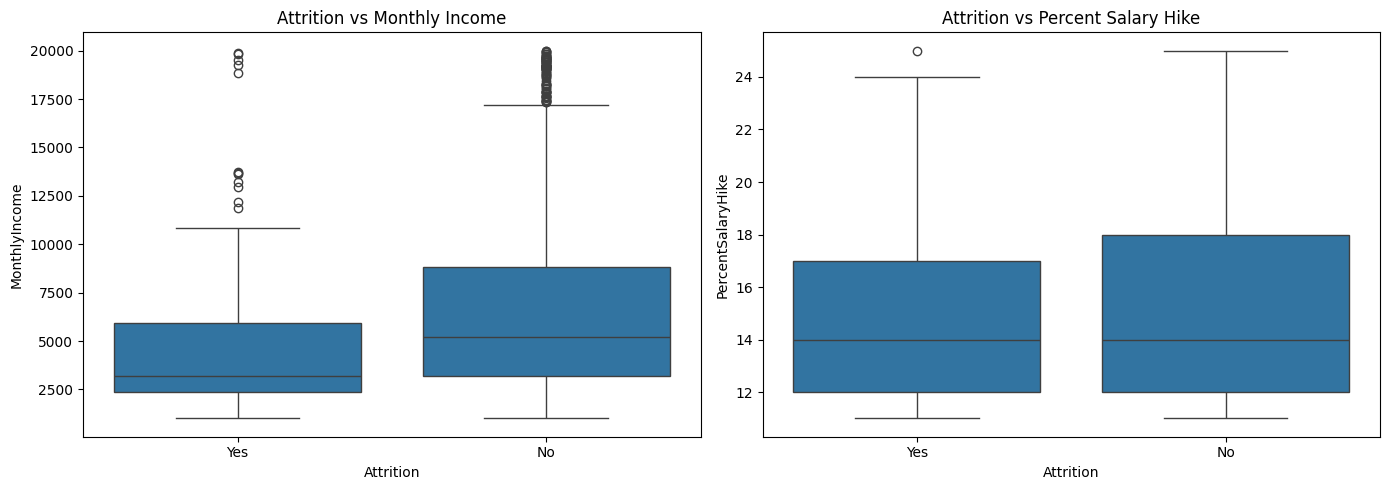

In [ ]:
#monthly income and Percentatge Salary Hike
fig, ax = plt.subplots(1,2, figsize=(14,5))

sns.boxplot(x="Attrition", y="MonthlyIncome", data=df, ax=ax[0])
ax[0].set_title("Attrition vs Monthly Income")

sns.boxplot(x="Attrition", y="PercentSalaryHike", data=df, ax=ax[1])
ax[1].set_title("Attrition vs Percent Salary Hike")

plt.tight_layout()
plt.show()

* Monthly Income: There is a clear "pay gap" between those who stay and those who leave. The median income for those who stay is over $5,000, while for those who leave, it sits significantly lower, near $3,000. Most "Leavers" are concentrated in the lower-earning bracket.

* Salary Hike Percentage: Surprisingly, this has almost zero impact. The median hike for both groups is identical at 14%, and the interquartile ranges (the middle 50%) overlap almost perfectly.

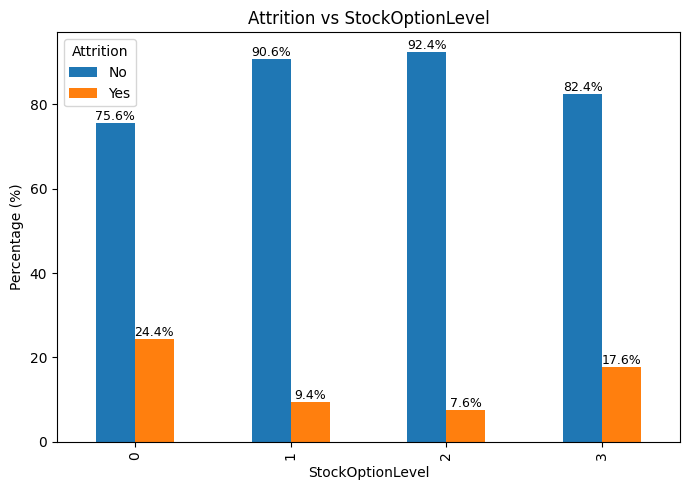

In [52]:
fig, ax = plt.subplots(figsize=(7,5))

temp = pd.crosstab(df["StockOptionLevel"], df["Attrition"], normalize="index")*100
temp.plot(kind="bar", ax=ax)

ax.set_title("Attrition vs StockOptionLevel")
ax.set_ylabel("Percentage (%)")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x()+p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

* Employees with 0 stock options have the highest attrition rate at 24.4%.
* Providing just Level 1 or 2 stock options slashes attrition to its lowest points (9.4% and 7.6%, respectively).
* Interestingly, attrition jumps back up to 17.6% for Level 3, suggesting that very high stock levels don't necessarily guarantee the highest retention.

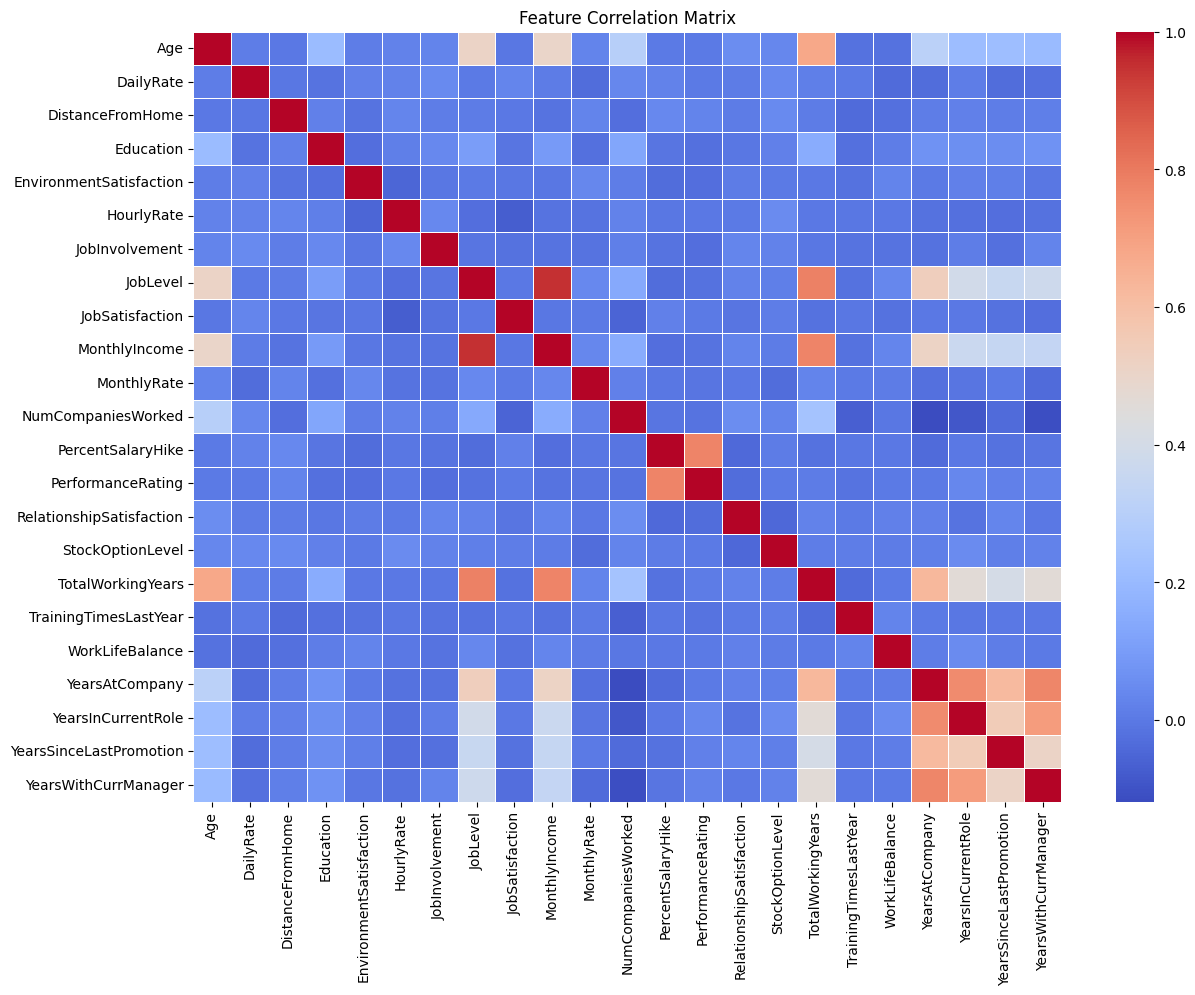

In [53]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Matrix")
plt.show()

**Key Insights & Business Recommendations**

1. **Overtime is a major driver of attrition**

Employees who work overtime show 30.5% attrition, compared to only 10.4% attrition for employees who do not work overtime — nearly 3× higher.

* *Business Recommendation: Organizations should monitor overtime workloads and introduce better workload distribution, flexible scheduling, or additional staffing to prevent employee burnout and reduce turnover.*


2. **Entry-level employees are leaving significantly more** 

Employees in Job Level 1 show 26.3% attrition, which is much higher compared to 4.7% attrition in Job Level 4 and 7.2% in Job Level 5.

* *Business Recommendation: Companies should implement strong onboarding programs, mentorship, and early career development plans to improve engagement and retention among entry-level employees.*


3. **Sales roles experience the highest turnover** 

Sales Representatives have the highest attrition at 39.8%, followed by Laboratory Technicians (23.9%) and Human Resources roles (23.1%).
At the department level, Sales shows the highest attrition at 20.6%, compared to 13.8% in R&D.

* *Business Recommendation: Organizations should review sales incentives, workload pressure, and career progression opportunities within sales roles to improve employee retention.*


4. **Lower job satisfaction strongly correlates with attrition** 

Employees with low job satisfaction (Level 1) have 22.8% attrition, while those with high satisfaction (Level 4) have only 11.3% attrition.

* *Business Recommendation: Regular employee engagement surveys, feedback mechanisms, and workplace improvement initiatives should be implemented to increase job satisfaction and reduce attrition.*


5. **Younger and less experienced employees are more likely to leave** 

Employees who leave tend to have lower median age and fewer total working years, with most attrition occurring among employees with shorter tenure at the company.

* *Business Recommendation: Organizations should focus on career growth opportunities, skill development programs, and retention strategies for early-career employees to improve long-term workforce stability.*